# 卷积神经网络、ResNet 残差连接与 ImageNet 迁移学习

本 Notebook 面向图像分类实验，目标是把 CNN 的核心模块、ResNet 的残差思想、ImageNet 预训练模型迁移学习，以及中间层特征图可视化串成一个可运行流程。

## 学习目标

1. 理解卷积操作的数学定义，以及它如何从图像中提取局部特征。
2. 理解池化层和全连接层在 CNN 中的作用。
3. 理解残差连接为什么能缓解深层网络中的梯度消失问题。
4. 掌握使用 ImageNet 预训练 ResNet 进行图像分类迁移学习的基本方法。
5. 使用 forward hook 提取 ResNet 中间层输出，并可视化 CNN 特征图。

## Notebook 运行说明

按顺序运行所有代码单元即可。特征图可视化部分会优先使用 ImageNet 预训练权重；如果当前环境无法下载权重，需要提前联网或把权重缓存到本机。迁移学习训练部分默认使用 `torchvision.datasets.ImageFolder` 数据格式。

## 1. 环境准备

本 Notebook 使用 PyTorch、torchvision、matplotlib 和 PIL。为了便于课堂或实验环境运行，下面的代码会自动选择 GPU 或 CPU。

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from PIL import Image, ImageDraw
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.1.2+cu118


## 2. 卷积操作的数学定义

对二维单通道图像 $X$ 和卷积核 $K$，卷积层常用的互相关形式可以写成：

$$
Y(i,j)=\sum_{u=0}^{k_h-1}\sum_{v=0}^{k_w-1} X(i+u,j+v)K(u,v)+b
$$

如果输入有多个通道，例如 RGB 图像 $X \in \mathbb{R}^{C_{in}\times H\times W}$，每个输出通道会对所有输入通道求和：

$$
Y_o(i,j)=\sum_{c=1}^{C_{in}}\sum_{u=0}^{k_h-1}\sum_{v=0}^{k_w-1} X_c(i+u,j+v)K_{o,c}(u,v)+b_o
$$

卷积层的关键特点：

- **局部连接**：每个输出只看输入图像的一个局部窗口。
- **参数共享**：同一个卷积核在整张图像上滑动，能够检测相同模式。
- **平移等变性**：图像中的边缘、纹理、形状移动时，对应特征响应也会移动。
- **层次特征**：浅层更常学习边缘和纹理，深层更常组合成部件和语义对象。

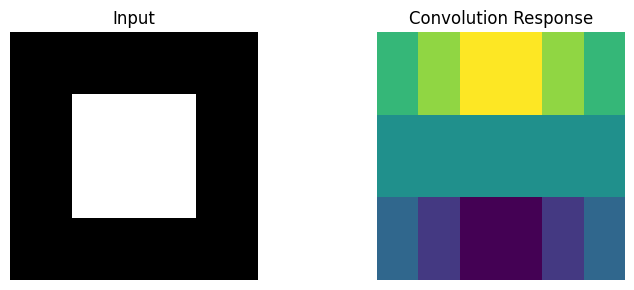

In [2]:
# 用一个简单卷积核观察边缘响应
demo = torch.zeros(1, 1, 8, 8)
demo[:, :, 2:6, 2:6] = 1.0

edge_kernel = torch.tensor(
    [[[-1.0, -1.0, -1.0],
      [ 0.0,  0.0,  0.0],
      [ 1.0,  1.0,  1.0]]]
).unsqueeze(0)

conv = nn.Conv2d(1, 1, kernel_size=3, bias=False)
conv.weight.data = edge_kernel

with torch.no_grad():
    response = conv(demo)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].imshow(demo[0, 0], cmap="gray")
axes[0].set_title("Input")
axes[1].imshow(response[0, 0], cmap="viridis")
axes[1].set_title("Convolution Response")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. 池化层与全连接层

**池化层**用于降低空间尺寸、扩大感受野，并让特征对小范围位移更稳健。常见池化方式包括最大池化和平均池化：

$$
\text{MaxPool}(X) = \max_{(u,v)\in \Omega} X(u,v)
$$

**全连接层**通常位于分类网络末端，把卷积骨干提取到的高级特征映射到类别得分：

$$
z = Wx+b
$$

在现代 CNN 中，常见结构是：卷积骨干提取特征，Global Average Pooling 压缩空间维度，最后用一个线性层输出类别 logits。

In [3]:
pool_input = torch.tensor([[[[1., 2., 0., 1.],
                            [3., 4., 1., 2.],
                            [0., 1., 5., 1.],
                            [2., 1., 0., 3.]]]])

max_pool = nn.MaxPool2d(kernel_size=2, stride=2)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)

print("Input:\n", pool_input[0, 0])
print("MaxPool:\n", max_pool(pool_input)[0, 0])
print("AvgPool:\n", avg_pool(pool_input)[0, 0])

Input:
 tensor([[1., 2., 0., 1.],
        [3., 4., 1., 2.],
        [0., 1., 5., 1.],
        [2., 1., 0., 3.]])
MaxPool:
 tensor([[4., 2.],
        [2., 5.]])
AvgPool:
 tensor([[2.5000, 1.0000],
        [1.0000, 2.2500]])


## 4. ResNet 残差连接的设计思想

普通深层网络希望直接学习目标映射 $H(x)$。ResNet 改为学习残差函数：

$$
F(x)=H(x)-x
$$

于是模块输出为：

$$
y = F(x) + x
$$

这个 identity shortcut 让梯度可以沿着加法路径直接向前传播。若损失为 $L$，则：

$$
\frac{\partial L}{\partial x} =
\frac{\partial L}{\partial y}
\left(
\frac{\partial F(x)}{\partial x} + I
\right)
$$

即使残差分支 $F(x)$ 的梯度很小，恒等分支中的 $I$ 仍然为梯度提供直接通道，因此深层网络更容易优化。ResNet 的重点不是让梯度永远不会变小，而是降低“层数变深导致优化困难”的风险。

In [4]:
class BasicResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        identity = x
        out = self.block(x)
        out = out + identity
        return self.relu(out)

block = BasicResidualBlock(channels=8)
x = torch.randn(2, 8, 16, 16)
y = block(x)
print("Input shape :", x.shape)
print("Output shape:", y.shape)

Input shape : torch.Size([2, 8, 16, 16])
Output shape: torch.Size([2, 8, 16, 16])


## 5. 加载 ImageNet 预训练 ResNet

迁移学习通常使用在 ImageNet 上预训练的模型作为特征提取器。ImageNet 包含大量自然图像类别，因此预训练 CNN 往往已经学到了通用边缘、纹理、形状和物体部件特征。

下面的函数兼容新版和旧版 torchvision：

- 新版：`models.ResNet50_Weights.IMAGENET1K_V2`
- 旧版：`models.resnet50(pretrained=True)`

In [5]:
def load_pretrained_resnet50():
    try:
        weights = models.ResNet50_Weights.IMAGENET1K_V2
        model = models.resnet50(weights=weights)
        preprocess = weights.transforms()
        categories = weights.meta.get("categories", None)
        print("Loaded ResNet50 with IMAGENET1K_V2 weights.")
    except AttributeError:
        model = models.resnet50(pretrained=True)
        preprocess = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])
        categories = None
        print("Loaded ResNet50 with pretrained=True.")

    model.eval()
    return model.to(device), preprocess, categories

model, preprocess, categories = load_pretrained_resnet50()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:10<00:00, 9.79MB/s]


Loaded ResNet50 with IMAGENET1K_V2 weights.


## 6. 准备一张输入图像

如果有自己的图片，把 `image_path` 改成图片路径即可。若 `image_path = None`，Notebook 会生成一张简单示例图片，便于测试完整流程。

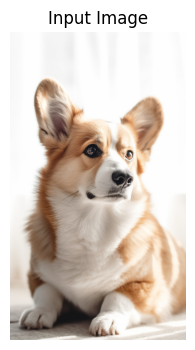

Input tensor shape: torch.Size([3, 224, 224])


In [ ]:
image_path =  "figures/dog.png"# 例如: "data/cat.jpg"

def create_demo_image(size=320):
    img = Image.new("RGB", (size, size), color=(245, 247, 250))
    draw = ImageDraw.Draw(img)
    draw.rectangle((70, 80, 250, 240), fill=(90, 140, 210), outline=(30, 60, 110), width=6)
    draw.ellipse((115, 45, 205, 135), fill=(235, 190, 80), outline=(120, 80, 20), width=5)
    draw.line((45, 270, 275, 270), fill=(50, 60, 70), width=8)
    return img

if image_path is None:
    img = create_demo_image()
else:
    img = Image.open(image_path).convert("RGB")

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")
plt.show()

input_tensor = preprocess(img).to(device)
print("Input tensor shape:", input_tensor.shape)

## 7. 使用预训练模型进行一次 ImageNet 分类预测

这一步展示预训练模型的直接推理流程。若使用示例合成图片，预测类别未必有实际语义；换成真实自然图像时结果更有参考价值。

In [9]:
with torch.no_grad():
    logits = model(input_tensor.unsqueeze(0))
    probs = torch.softmax(logits, dim=1)[0]
    top_probs, top_idxs = probs.topk(5)

for rank, (prob, idx) in enumerate(zip(top_probs, top_idxs), start=1):
    label = categories[idx] if categories is not None else f"class_{idx.item()}"
    print(f"{rank}. {label:25s} probability={prob.item():.4f}")

1. Pembroke                  probability=0.3742
2. Cardigan                  probability=0.1104
3. papillon                  probability=0.0036
4. Border collie             probability=0.0021
5. Eskimo dog                probability=0.0019


## 8. 可视化 CNN 中间层特征图

下面使用 forward hook 提取 `model.layer1` 的输出。`layer1` 的特征图形状通常是 `(C, H, W)`，其中：

- `C`：通道数，每个通道可以理解为一种检测器响应。
- `H, W`：空间尺寸，表示该特征在图像不同位置上的激活强度。

颜色越亮通常代表该通道在对应位置响应越强。不同通道可能关注边缘、颜色过渡、局部纹理或更复杂的形状模式。

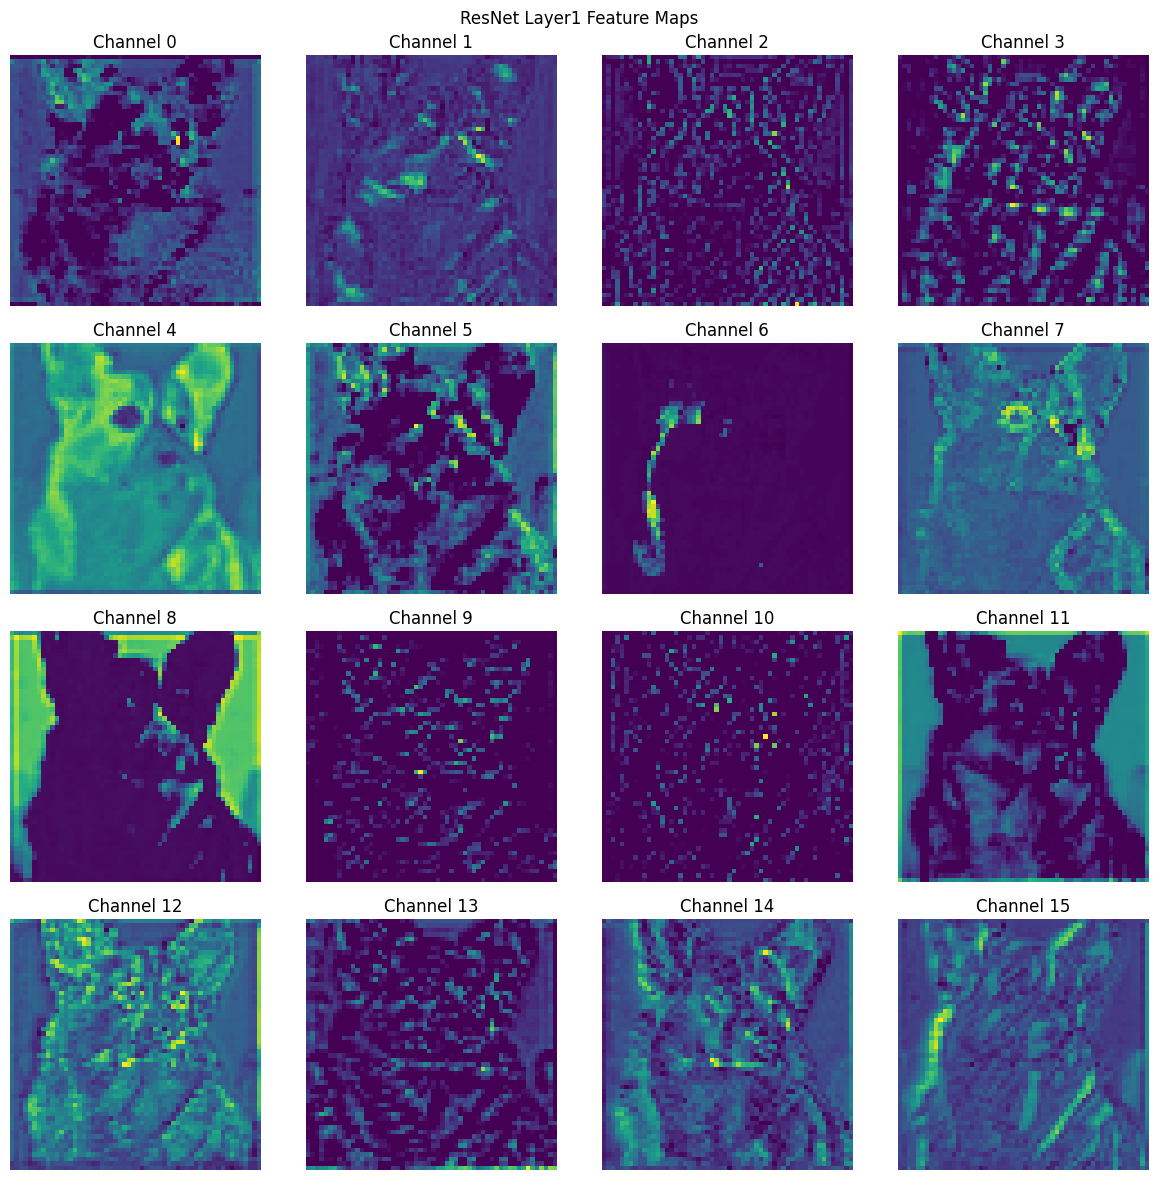

Layer1 feature map shape: (256, 56, 56)
Saved: feature_maps.pdf and feature_maps.png


In [10]:
# 注册 hook 提取中间层输出
feature_maps = {}

def hook_fn(module, input, output):
    feature_maps["layer1"] = output.detach().cpu()

hook = model.layer1.register_forward_hook(hook_fn)

# 前向传播并可视化
with torch.no_grad():
    output = model(input_tensor.unsqueeze(0))

# 可视化 layer1 的前 16 个特征图
fmap = feature_maps["layer1"][0]  # (C, H, W)
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    if i < fmap.shape[0]:
        ax.imshow(fmap[i].numpy(), cmap="viridis")
        ax.set_title(f"Channel {i}")
    ax.axis("off")

plt.suptitle("ResNet Layer1 Feature Maps")
plt.tight_layout()
plt.savefig("feature_maps.pdf", dpi=150, bbox_inches="tight")
plt.savefig("feature_maps.png", dpi=150, bbox_inches="tight")
plt.show()
hook.remove()

print("Layer1 feature map shape:", tuple(fmap.shape))
print("Saved: feature_maps.pdf and feature_maps.png")

## 9. ImageNet 预训练模型的迁移学习

迁移学习的常见流程：

1. 准备自己的分类数据集，采用 `ImageFolder` 目录结构。
2. 加载 ImageNet 预训练模型。
3. 替换最后的分类层，使输出类别数等于自己的任务类别数。
4. 先冻结大部分卷积骨干，只训练新的分类层。
5. 如果数据量足够，再解冻后几层，用较小学习率微调。

`ImageFolder` 推荐目录结构：

```text
data/
  train/
    class_a/
      img001.jpg
    class_b/
      img002.jpg
  val/
    class_a/
      img101.jpg
    class_b/
      img102.jpg
```

## 11. 小结

本 Notebook 完成了以下内容：

- 给出卷积操作的数学定义，并用简单卷积核演示特征响应。
- 解释池化层和全连接层在 CNN 中的作用。
- 从公式角度解释 ResNet 残差连接如何为梯度提供直接传播路径。
- 加载 ImageNet 预训练 ResNet50，并展示分类推理流程。
- 使用 forward hook 提取 `layer1` 的中间层输出，完成前 16 个特征图可视化，并保存为 `feature_maps.pdf`。

## 思考题

1. 为什么迁移学习常常先冻结卷积骨干，再逐步解冻部分高层？
2. 对小数据集而言，过强的数据增强可能带来什么问题？

## 思考题回答

### 1. 为什么迁移学习常常先冻结卷积骨干，再逐步解冻部分高层？

迁移学习中，预训练 CNN（如 ImageNet 上训练的 ResNet50）已经学习到了大量通用视觉特征。卷积网络不同层具有不同的特征表达能力：

- **浅层卷积层**主要提取边缘、纹理、颜色等底层视觉特征，这些特征具有较强的通用性，与具体任务关联较小；
- **中高层卷积层**逐渐学习更加抽象的结构特征，如目标形状、局部语义信息，与具体任务的数据分布更加相关。

因此，在小规模数据集上进行迁移学习时，通常先冻结卷积骨干网络，使已有的通用特征保持不变，只训练新的分类层：

1. **减少可训练参数数量**，降低模型过拟合风险；
2. **避免小数据集破坏预训练模型已经学习到的有效特征**；
3. **加快训练速度，提高训练稳定性**。

当模型初步适应目标任务后，可以逐步解冻靠近输出端的高层卷积层，使其根据新任务的数据分布进行微调，从而获得更强的任务相关特征表达能力。

因此，“冻结 → 部分解冻”的策略本质上是在**保持通用知识和学习任务特定知识之间取得平衡**。

---

### 2. 对小数据集而言，过强的数据增强可能带来什么问题？

数据增强可以通过扩充训练样本，提高模型的泛化能力，但对于小数据集而言，如果增强方式过于强烈，可能产生以下问题：

1. **引入不符合真实分布的样本**

过强的数据变换可能改变目标的重要特征，例如过大的旋转、裁剪、颜色扰动等可能使图像偏离真实应用场景，使模型学习到错误规律。

2. **降低类别判别信息**

某些增强操作可能破坏目标关键区域，例如：

- 裁剪掉目标主体；
- 强烈模糊导致纹理信息丢失；
- 过度颜色变化改变目标本身特征。

这会导致模型难以区分类别。

3. **造成训练困难**

增强后的样本与原始样本差异过大，会增加训练数据分布的复杂性，使模型难以收敛，甚至出现欠拟合现象。

4. **产生“增强噪声”**

对于小数据集，模型本身能够学习的信息有限，过强增强可能让模型更多关注人工生成的变化，而不是实际任务中的有效特征。

因此，小数据集中的数据增强应遵循**适度原则**，选择符合实际场景的数据变化方式，例如轻微旋转、随机裁剪、水平翻转、亮度调整等，而避免过强或不符合物理规律的增强操作。